## Training the Random Forest

In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import accuracy_score, precision_recall_curve, precision_recall_fscore_support, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier









### Load the prepared csv

In [10]:
file_path = '/home/ubuntu/work/saved_data/landsat_disturbance_detection/clean_1D_U_Net/deep_disturbance/Random_Forest/Data_for_RF.csv'
df = pd.read_csv(file_path, delimiter=',', index_col=False)

print(df.head(10))
print(df.columns)

   year  numerical_id  class      NDVI       NBR     TCB     TCG    TCW  \
0  1986             1      0  0.846658  0.697250  3981.0  2713.0 -168.0   
1  1987             1      0  0.884108  0.714342  3884.0  2926.0 -127.0   
2  1988             1      0  0.862136  0.678677  4514.0  3146.0 -284.0   
3  1989             1      0  0.855061  0.706518  4341.0  2956.0 -218.0   
4  1990             1      0  0.808742  0.670267  4332.0  2699.0 -197.0   
5  1991             1      0  0.893613  0.683797  4682.0  3434.0 -278.0   
6  1992             1      0  0.882402  0.719419  4012.0  3056.0 -183.0   
7  1993             1      0  0.895533  0.703258  4907.0  3728.0 -209.0   
8  1994             1      0  0.845774  0.699545  4516.0  3108.0 -101.0   
9  1995             1      0  0.876190  0.754110  4479.0  3391.0  115.0   

        DIn  NDVI_diff  NBR_diff  TCB_diff  TCG_diff  TCW_diff  DIn_diff  
0 -2.701317  -0.056603  0.005750      17.0    -286.0     228.0  0.421553  
1 -3.254909   0.037450  

### Splitting the data in train and test

In [11]:
# Split the data into training and testing sets
'''X_train, X_test, y_train, y_test = train_test_split(df[['NDVI', 'NDVI_diff', 'NBR', 'NBR_diff']], 
                                                    df['class'], 
                                                    test_size=0.2, 
                                                    stratify=df['class'], ### check ?!
                                                    random_state=42)'''

from sklearn.model_selection import train_test_split

# Get unique numerical_ids
unique_ids = df['numerical_id'].unique()

# Split the unique numerical_ids into training and testing sets
train_ids, test_ids = train_test_split(unique_ids, 
                                    test_size=0.2, 
                                    random_state=42, 
                                    stratify=None)  # No stratification here, it might not be necessary

# Now split the data based on these numerical_id splits
train_df = df[df['numerical_id'].isin(train_ids)]
test_df = df[df['numerical_id'].isin(test_ids)]

# Separate features and target for training
X_train = train_df[['NDVI', 'NDVI_diff', 'NBR', 'NBR_diff', 'TCB', 'TCB_diff', 'TCG', 'TCG_diff', 'TCW', 'TCW_diff', 'DIn', 'DIn_diff']]
y_train = train_df['class']

# Separate features and target for testing
X_test = test_df[['NDVI', 'NDVI_diff', 'NBR', 'NBR_diff', 'TCB', 'TCB_diff', 'TCG', 'TCG_diff', 'TCW', 'TCW_diff', 'DIn', 'DIn_diff']]
y_test = test_df['class']



In [12]:
# check the resulting shapes:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (439586, 12)
y_train shape: (439586,)
X_test shape: (109938, 12)
y_test shape: (109938,)


### Train the Random Forest

In [13]:
#model = RandomForestClassifier(n_estimators=25, max_depth=7, max_features=None, random_state=0)

model = XGBClassifier(
    n_estimators=1000,        # More trees often better for XGBoost
    max_depth=6,             # XGBoost typically uses shallower trees
    learning_rate=0.1,       # Step size shrinkage
    subsample=0.8,           # Fraction of samples used for each tree
    colsample_bytree=0.8,    # Fraction of features used for each tree
    random_state=0,
    eval_metric='logloss',
    scale_pos_weight=100
)

model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [14]:
# Assume you have a trained RandomForestClassifier model
joblib.dump(model, "random_forest_model.pkl")

['random_forest_model.pkl']

### Testing: Classification Report and Confusion Matrix

In [15]:
preds = model.predict(X_test)

print(y_test.shape)
print(preds.shape)

# Compute overall accuracy
accuracy = accuracy_score(y_test, preds)
print(f"Accuracy: {accuracy:.4f}")

# Generate a detailed classification report (includes precision, recall, F1-score for each class)
report = classification_report(y_test, preds, target_names=["No Disturbance",  "Disturbance"])
print(report)

(109938,)
(109938,)
Accuracy: 0.9958
                precision    recall  f1-score   support

No Disturbance       1.00      1.00      1.00    109464
   Disturbance       0.51      0.57      0.54       474

      accuracy                           1.00    109938
     macro avg       0.75      0.78      0.77    109938
  weighted avg       1.00      1.00      1.00    109938



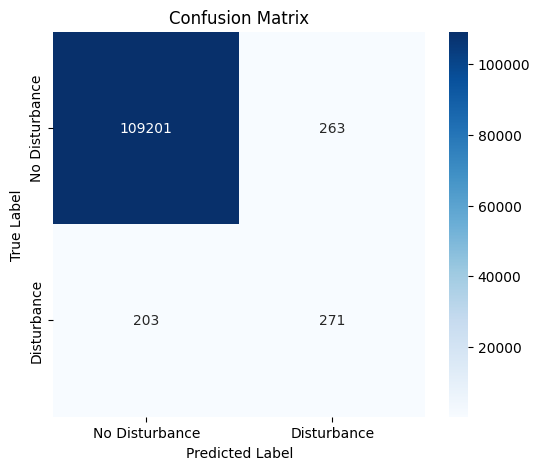

In [16]:
# Compute confusion matrix
cm = confusion_matrix(y_test, preds)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["No Disturbance", "Disturbance"], yticklabels=["No Disturbance", "Disturbance"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()